# dataset labeling tool

## panel 1: generate label.csv from images

In [1]:
import os
import pandas as pd
from pathlib import Path

# configuration
DATASET_DIR = 'dataset_head'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
OUTPUT_CSV = os.path.join(DATASET_DIR, 'label.csv')

# get all image files
image_extensions = ['.jpg', '.jpeg', '.png']
image_files = []

for file in sorted(os.listdir(IMAGES_DIR)):
    if any(file.lower().endswith(ext) for ext in image_extensions):
        image_files.append(file)

print(f'found {len(image_files)} images in {IMAGES_DIR}')

# create dataframe with default congestion_score = 0
data = {
    'image_name': image_files,
    'congestion_score': [0] * len(image_files)
}

df = pd.DataFrame(data)

# save to csv
df.to_csv(OUTPUT_CSV, index=False)

print(f'\nsaved to: {OUTPUT_CSV}')
print(f'\npreview:')
print(df.head(10))
print(f'\ntotal rows: {len(df)}')

## panel 2: extract cv2 features into label_cv2.csv

### features được extract:
1. **object_count**: số lượng phương tiện (contour detection)
2. **edge_density**: mật độ edges (canny edge detection)
3. **avg_gradient**: độ phức tạp texture (sobel)
4. **orientation_variance**: độ lộn xộn (variance của angles)
5. **spatial_density**: mật độ không gian (khoảng cách giữa objects)
6. **laplacian_variance**: độ sắc nét (laplacian)

### output: label_cv2.csv
- mỗi feature là 1 cột
- không tính congestion score
- dùng để phân tích và manual labeling

In [36]:
import cv2
import numpy as np
import pandas as pd
import os
from math import log2

DATASET_DIR = 'dataset'
IMAGES_DIR = os.path.join(DATASET_DIR, 'images')
OUTPUT_CSV = os.path.join(DATASET_DIR, 'label_cv2_v2.csv')

EDGE_LOW = 60
EDGE_HIGH = 160
MIN_CONTOUR_AREA_RATIO = 0.0003
ORIENTATION_BINS = 18
LOCAL_RADIUS_RATIO = 0.08

def edge_orientation_features(edges):
    sobelx = cv2.Sobel(edges, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(edges, cv2.CV_64F, 0, 1, ksize=3)

    angles = np.arctan2(sobely, sobelx)
    angles = angles[edges > 0]

    if len(angles) == 0:
        return 0.0, 0.0

    angles = np.degrees(angles)
    angles[angles < 0] += 180

    hist, _ = np.histogram(
        angles,
        bins=ORIENTATION_BINS,
        range=(0, 180),
        density=True
    )

    hist = hist[hist > 0]

    entropy = -np.sum(hist * np.log2(hist))
    variance = np.var(angles)

    return entropy, variance


def spatial_density_features(centers, h, w):
    if len(centers) < 2:
        return 0.0, 0.0

    centers = np.array(centers)
    diag = np.sqrt(h * h + w * w)

    dists = []
    local_counts = []

    radius = LOCAL_RADIUS_RATIO * diag

    for i in range(len(centers)):
        diff = centers - centers[i]
        dist = np.sqrt((diff ** 2).sum(axis=1))
        dist = dist[dist > 0]

        if len(dist) > 0:
            dists.append(dist.min())
            local_counts.append(np.sum(dist < radius))

    mean_nn_dist = np.mean(dists) / diag if dists else 0.0
    local_density = np.mean(local_counts) if local_counts else 0.0

    return mean_nn_dist, local_density


def extract_image_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None

    h_raw, w_raw = img.shape[:2]

    crop_top = 60 
    img = img[crop_top:h_raw, 0:w_raw]

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # gray = cv2.equalizeHist(gray)
    h, w = gray.shape

    edges = cv2.Canny(gray, EDGE_LOW, EDGE_HIGH)
    edge_density = np.sum(edges > 0) / (h * w)
    
    # Có thể thêm bước này để nối liền các nét đứt trước khi tìm contour
    # kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    # edges = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    min_area = MIN_CONTOUR_AREA_RATIO * h * w
    max_area = 0.98 * h * w # Loại bỏ contour to bằng cả cái ảnh (viền)

    valid_contours = []
    for c in contours:
        area = cv2.contourArea(c)
        if area > min_area and area < max_area:
            valid_contours.append(c)

    # --- SỬA ĐỔI TẠI ĐÂY ---
    if valid_contours:
        # Tạo mask đen
        mask = np.zeros((h, w), dtype=np.uint8)
        # Vẽ các contour hợp lệ lên mask dưới dạng khối đặc (FILLED)
        cv2.drawContours(mask, valid_contours, -1, 255, thickness=cv2.FILLED)
        # Đếm số pixel
        contour_area_ratio = np.count_nonzero(mask) / (h * w)
    else:
        contour_area_ratio = 0.0
    # -----------------------

    centers = []
    for c in valid_contours:
        M = cv2.moments(c)
        if M['m00'] != 0:
            centers.append([
                M['m10'] / M['m00'],
                M['m01'] / M['m00']
            ])

    orient_entropy, orient_variance = edge_orientation_features(edges)
    mean_nn_dist, local_density = spatial_density_features(centers, h, w)

    return {
        'edge_density': round(edge_density, 4),
        'contour_area_ratio': round(contour_area_ratio, 4),
        'orientation_entropy': round(orient_entropy, 4),
        'orientation_variance': round(orient_variance, 2),
        'mean_nn_dist_norm': round(mean_nn_dist, 4),
        'local_density': round(local_density, 2)
    }
image_extensions = ('.jpg', '.jpeg', '.png')
image_files = sorted(f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(image_extensions))

data = {k: [] for k in [
    'image_name',
    'edge_density',
    'contour_area_ratio',
    'orientation_entropy',
    'orientation_variance',
    'mean_nn_dist_norm',
    'local_density'
]}

print(f'extracting features from {len(image_files)} images')

for idx, image_name in enumerate(image_files):
    print(f'[{idx + 1}/{len(image_files)}] {image_name}')
    path = os.path.join(IMAGES_DIR, image_name)

    feat = extract_image_features(path)
    if feat is None:
        continue

    data['image_name'].append(image_name)
    for k in feat:
        data[k].append(feat[k])

df = pd.DataFrame(data)
df.to_csv(OUTPUT_CSV, index=False)

print(f'saved to {OUTPUT_CSV}')


extracting features from 1393 images
[1/1393] 20251126_161747.jpg
[2/1393] 20251126_161808.jpg
[3/1393] 20251126_161952.jpg
[4/1393] 20251126_162014.jpg
[5/1393] 20251126_162036.jpg
[6/1393] 20251126_162057.jpg
[7/1393] 20251126_162120.jpg
[8/1393] 20251127_072559.jpg
[9/1393] 20251127_072617.jpg
[10/1393] 20251127_072635.jpg
[11/1393] 20251127_072654.jpg
[12/1393] 20251127_072712.jpg
[13/1393] 20251127_072730.jpg
[14/1393] 20251127_072749.jpg
[15/1393] 20251127_072808.jpg
[16/1393] 20251127_072825.jpg
[17/1393] 20251127_072843.jpg
[18/1393] 20251127_072908.jpg
[19/1393] 20251127_072928.jpg
[20/1393] 20251127_072945.jpg
[21/1393] 20251127_073003.jpg
[22/1393] 20251127_073021.jpg
[23/1393] 20251127_073038.jpg
[24/1393] 20251127_073056.jpg
[25/1393] 20251127_073114.jpg
[26/1393] 20251127_073131.jpg
[27/1393] 20251127_073149.jpg
[28/1393] 20251127_073206.jpg
[29/1393] 20251127_073224.jpg
[30/1393] 20251127_073241.jpg
[31/1393] 20251127_073259.jpg
[32/1393] 20251127_073317.jpg
[33/1393] 20

saved visualization to: dataset\features_visualization.png


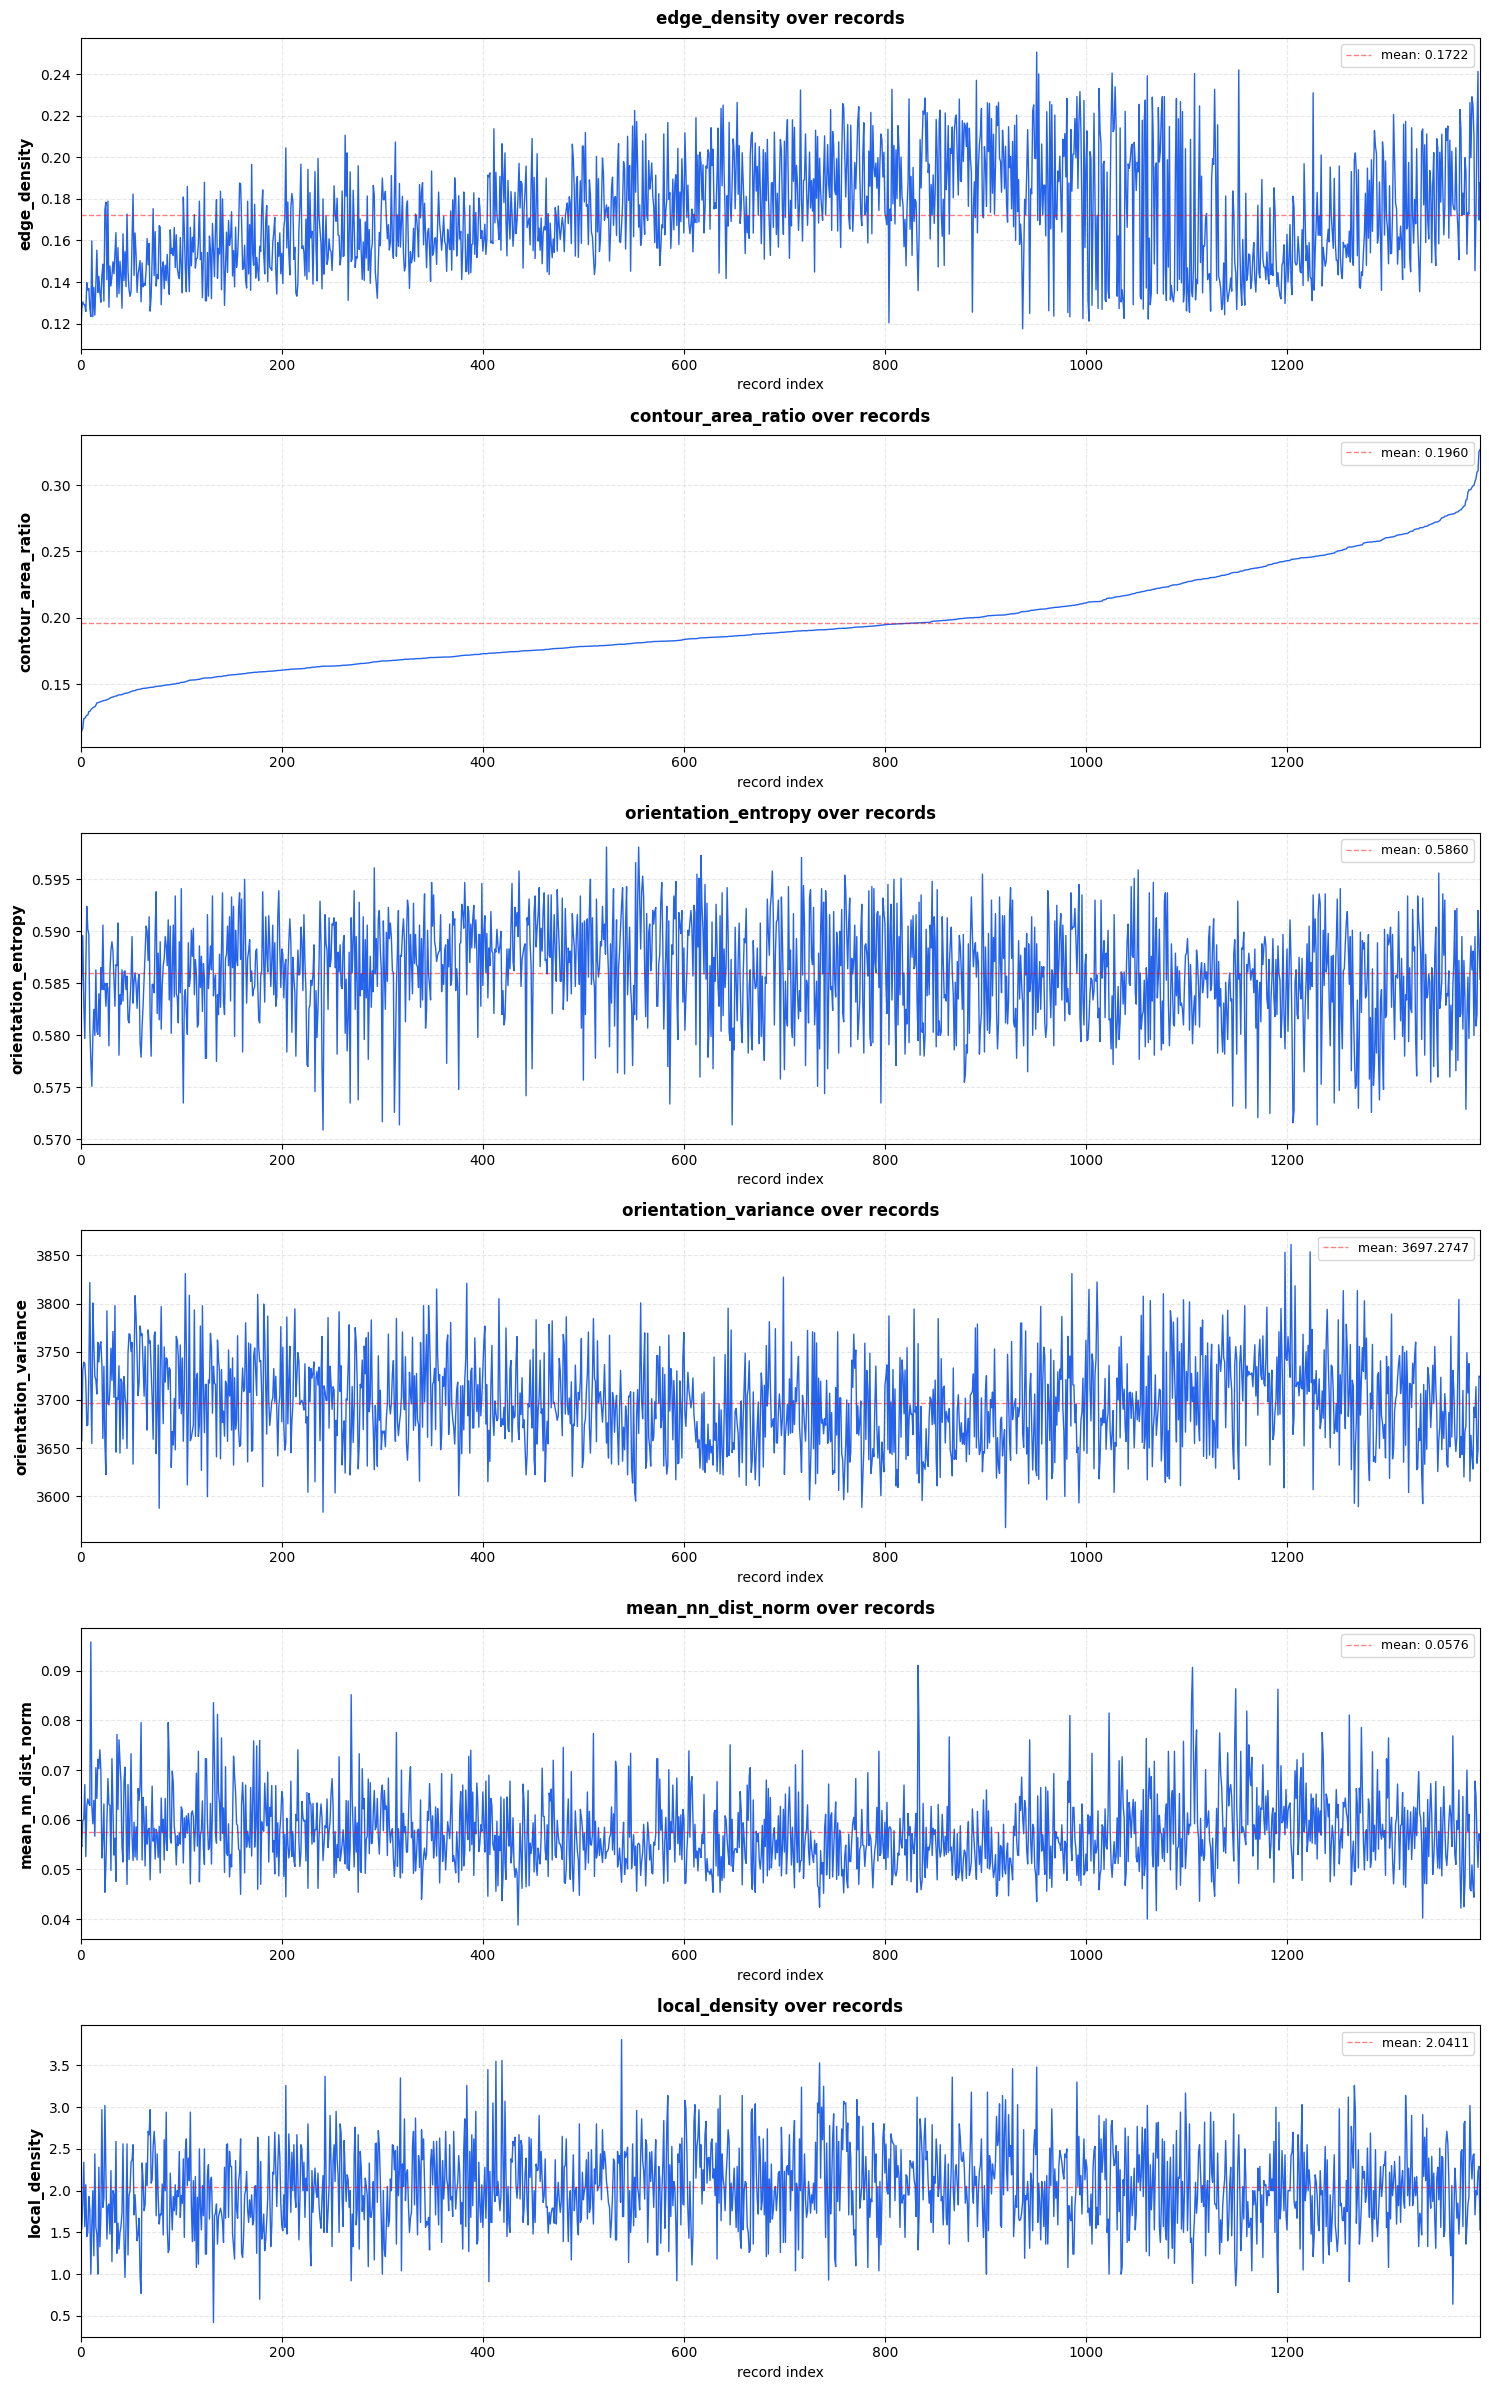


total records: 1393
features plotted: edge_density, contour_area_ratio, orientation_entropy, orientation_variance, mean_nn_dist_norm, local_density


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# configuration
DATASET_DIR = 'dataset'
CSV_FILE = os.path.join(DATASET_DIR, 'label_cv2_v2.csv')

# read csv
df = pd.read_csv(CSV_FILE)

# sort by first column (image_name)
# image_name,edge_density,contour_area_ratio,orientation_entropy,orientation_variance,mean_nn_dist_norm,local_density
# 0: image_name 
# 1: edge_density
# 2: contour_area_ratio
# 3: orientation_entropy
# 4: orientation_variance
# 5: mean_nn_dist_norm
# 6: local_density
df = df.sort_values(by=df.columns[2])

# get numeric columns (exclude image_name)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# create figure with subplots (one for each numeric column)
n_plots = len(numeric_cols)
fig, axes = plt.subplots(n_plots, 1, figsize=(15, 4 * n_plots))

# if only one plot, axes is not a list
if n_plots == 1:
    axes = [axes]

# plot each feature
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # plot line chart
    ax.plot(range(len(df)), df[col], linewidth=1, marker='', color='#2563eb')
    
    # styling
    ax.set_xlabel('record index', fontsize=10)
    ax.set_ylabel(col, fontsize=11, fontweight='bold')
    ax.set_title(f'{col} over records', fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xlim(0, len(df) - 1)
    
    # add mean line
    mean_val = df[col].mean()
    ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5, label=f'mean: {mean_val:.4f}')
    ax.legend(loc='upper right', fontsize=9)

# adjust layout
plt.tight_layout()

# save figure
output_path = os.path.join(DATASET_DIR, 'features_visualization.png')
plt.savefig(output_path, dpi=150, bbox_inches='tight')
print(f'saved visualization to: {output_path}')

# show plot
plt.show()

print(f'\ntotal records: {len(df)}')
print(f'features plotted: {", ".join(numeric_cols)}')


In [38]:
import pandas as pd
import os

# configuration
DATASET_DIR = 'dataset'
FEATURES_CSV = os.path.join(DATASET_DIR, 'label_cv2_v2.csv')
LABEL_CSV = os.path.join(DATASET_DIR, 'label.csv')

import math

def compute_congestion_score(
    edge_density,
    contour_area_ratio,
    orientation_entropy,
    mean_nn_dist_norm,
    local_density
):
    score = 0.0

    # ===============================
    # 1. VEHICLE LOAD (xương sống)
    # ===============================
    if edge_density > 0.24:
        score += 0.35
    elif edge_density > 0.22:
        score += 0.30
    elif edge_density > 0.19:
        score += 0.25
    elif edge_density > 0.16:
        score += 0.18
    elif edge_density > 0.13:
        score += 0.12
    else:
        score += 0.08

    # ===============================
    # 2. OCCUPANCY / CHEN CHÚC
    # ===============================
    if contour_area_ratio > 0.30:
        score += 0.30
    elif contour_area_ratio > 0.24:
        score += 0.22
    elif contour_area_ratio > 0.20:
        score += 0.16
    elif contour_area_ratio > 0.17:
        score += 0.10
    elif contour_area_ratio > 0.14:
        score += 0.06

    # ===============================
    # 3. PROXIMITY (tăng dần, KHÔNG gate)
    # ===============================
    if mean_nn_dist_norm < 0.048:
        score += 0.22
    elif mean_nn_dist_norm < 0.052:
        score += 0.18
    elif mean_nn_dist_norm < 0.056:
        score += 0.12
    elif mean_nn_dist_norm < 0.060:
        score += 0.07

    # ===============================
    # 4. LOCAL DENSITY (khuếch đại)
    # ===============================
    if local_density > 2.7:
        score += 0.12
    elif local_density > 2.4:
        score += 0.08
    elif local_density > 2.0:
        score += 0.05
    elif local_density > 1.8:
        score += 0.03

    # ===============================
    # 5. CHAOS (nhẹ, tránh phá score)
    # ===============================
    if orientation_entropy > 0.592:
        score += 0.05
    elif orientation_entropy > 0.589:
        score += 0.03

    # ===============================
    # 6. TRUE CONGESTION BOOST
    # (chỉ khi hội đủ điều kiện)
    # ===============================
    if (
        edge_density > 0.23 and
        contour_area_ratio > 0.26 and
        mean_nn_dist_norm < 0.053
    ):
        score += 0.18

    return round(min(score, 0.99), 2)

# read features csv
df_features = pd.read_csv(FEATURES_CSV)
print(f"loaded {len(df_features)} records from {FEATURES_CSV}")

# read label csv (để lấy image names)
df_label = pd.read_csv(LABEL_CSV)
print(f"loaded {len(df_label)} records from {LABEL_CSV}")

# compute congestion score for each row
print("\ncomputing congestion scores...")
scores = []

for idx, row in df_features.iterrows():
    score = compute_congestion_score(
        edge_density=row['edge_density'],
        contour_area_ratio=row['contour_area_ratio'],
        orientation_entropy=row['orientation_entropy'],
        mean_nn_dist_norm=row['mean_nn_dist_norm'],
        local_density=row['local_density']
    )
    scores.append(score)
    
    # print sample progress
    if (idx + 1) % 200 == 0:
        print(f"  processed {idx + 1}/{len(df_features)} images...")

# add scores to features dataframe
df_features['congestion_score'] = scores

# merge with label dataframe based on image_name
df_label = df_label.merge(
    df_features[['image_name', 'congestion_score']], 
    on='image_name', 
    how='left',
    suffixes=('_old', '')
)

# remove old score column if exists
if 'congestion_score_old' in df_label.columns:
    df_label = df_label.drop(columns=['congestion_score_old'])

# save updated label csv
df_label.to_csv(LABEL_CSV, index=False)

print(f"\n✓ saved {len(df_label)} labeled records to {LABEL_CSV}")

# show statistics
print("\ncongestion score statistics:")
print(df_label['congestion_score'].describe())

print("\nscore distribution:")
low = len(df_label[df_label['congestion_score'] < 0.4])
mid = len(df_label[(df_label['congestion_score'] >= 0.4) & (df_label['congestion_score'] < 0.65)])
high = len(df_label[df_label['congestion_score'] >= 0.65])

print(f"  không tắc / tắc nhẹ (< 0.4):        {low:4d} ({low/len(df_label)*100:.1f}%)")
print(f"  đông / tắc vừa (0.4 - 0.65):        {mid:4d} ({mid/len(df_label)*100:.1f}%)")
print(f"  tắc nghẽn nghiêm trọng (>= 0.65):   {high:4d} ({high/len(df_label)*100:.1f}%)")

print(f"\npreview:")
print(df_label.head(10))


loaded 1393 records from dataset\label_cv2_v2.csv
loaded 1393 records from dataset\label.csv

computing congestion scores...
  processed 200/1393 images...
  processed 400/1393 images...
  processed 600/1393 images...
  processed 800/1393 images...
  processed 1000/1393 images...
  processed 1200/1393 images...

✓ saved 1393 labeled records to dataset\label.csv

congestion score statistics:
count    1393.000000
mean        0.436533
std         0.157051
min         0.080000
25%         0.310000
50%         0.430000
75%         0.550000
max         0.990000
Name: congestion_score, dtype: float64

score distribution:
  không tắc / tắc nhẹ (< 0.4):         588 (42.2%)
  đông / tắc vừa (0.4 - 0.65):         655 (47.0%)
  tắc nghẽn nghiêm trọng (>= 0.65):    150 (10.8%)

preview:
            image_name  congestion_score
0  20251126_161747.jpg              0.52
1  20251126_161808.jpg              0.41
2  20251126_161952.jpg              0.40
3  20251126_162014.jpg              0.65
4  2025112

TRAIN CNN

In [40]:
import os
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models

# 1. dataset class
class TrafficDataset(Dataset):
    def __init__(self, csv_path, image_dir, transform=None):
        df = pd.read_csv(csv_path)
        self.image_dir = image_dir
        self.transform = transform
        
        # filter out images that don't exist
        valid_indices = []
        print(f"checking {len(df)} images...")
        existing_count = 0
        for idx, row in df.iterrows():
            img_path = os.path.join(self.image_dir, row["image_name"])
            if os.path.exists(img_path):
                valid_indices.append(idx)
                existing_count += 1
        
        self.data = df.iloc[valid_indices].reset_index(drop=True)
        print(f"filtered dataset: {existing_count}/{len(df)} images found.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = self.data.iloc[idx]["image_name"]
        score_str = str(self.data.iloc[idx]["congestion_score"])
        try:
            y = float(score_str.replace(',', '.'))
        except ValueError:
            y = 0.0

        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(y, dtype=torch.float32)

# 2. transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. prepare dataloader
CSV_PATH = 'dataset/label.csv'
IMG_DIR = 'dataset/images'

print(f"loading data from {CSV_PATH}")

# create dataset with transform none first
temp_dataset = TrafficDataset(CSV_PATH, IMG_DIR, transform=None)
n_samples = len(temp_dataset)
n_train = int(0.8 * n_samples)
n_val = n_samples - n_train

# fixed split with seed
generator = torch.Generator().manual_seed(42)
train_indices, val_indices = random_split(range(n_samples), [n_train, n_val], generator=generator)

# create separate dataset instances for different transforms
train_ds_full = TrafficDataset(CSV_PATH, IMG_DIR, transform=train_transform)
val_ds_full = TrafficDataset(CSV_PATH, IMG_DIR, transform=val_transform)

train_dataset = torch.utils.data.Subset(train_ds_full, train_indices.indices)
val_dataset = torch.utils.data.Subset(val_ds_full, val_indices.indices)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"data loaded: {len(train_dataset)} train images, {len(val_dataset)} val images")

# 4. model definition
class CongestionCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # load pretrained resnet18
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])

        self.regressor = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = x.view(x.size(0), -1)
        x = self.regressor(x)
        return x.squeeze(1)

# 5. setup training
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using device: {device}")

model = CongestionCNN().to(device)

# freeze feature extractor initially
for param in model.feature_extractor.parameters():
    param.requires_grad = False

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.regressor.parameters(), lr=1e-3)

# 6. training functions
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
    return total_loss / len(loader)

# 7. run training - phase 1
print("\nstarting initial training (head only)...")
for epoch in range(10): 
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    print(f"epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

# 8. fine-tuning - phase 2
print("\nstarting fine-tuning (last 2 layers + head)...")
for param in model.feature_extractor[-2:].parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.feature_extractor.parameters(), "lr": 1e-5},
    {"params": model.regressor.parameters(), "lr": 1e-4}
])

for epoch in range(10): 
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    print(f"fine-tune epoch {epoch+1}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}")

print("\ntraining complete.")

# 9. save model
MODEL_DIR = "model"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'congestion_cnn_model.pth')
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'ResNet18-based CNN',
    'input_size': (224, 224),
    'output_range': (0, 1),
}, MODEL_SAVE_PATH)
print(f"model saved to: {MODEL_SAVE_PATH}")


loading data from dataset/label.csv
checking 1393 images...
filtered dataset: 1393/1393 images found.
checking 1393 images...
filtered dataset: 1393/1393 images found.
checking 1393 images...
filtered dataset: 1393/1393 images found.
data loaded: 1114 train images, 279 val images
using device: cpu

starting initial training (head only)...
epoch 1: train_loss=0.0109, val_loss=0.0069
epoch 2: train_loss=0.0068, val_loss=0.0063
epoch 3: train_loss=0.0066, val_loss=0.0065
epoch 4: train_loss=0.0061, val_loss=0.0060
epoch 5: train_loss=0.0055, val_loss=0.0062
epoch 6: train_loss=0.0061, val_loss=0.0067
epoch 7: train_loss=0.0057, val_loss=0.0061
epoch 8: train_loss=0.0055, val_loss=0.0062
epoch 9: train_loss=0.0052, val_loss=0.0062
epoch 10: train_loss=0.0056, val_loss=0.0072

starting fine-tuning (last 2 layers + head)...
fine-tune epoch 1: train_loss=0.0047, val_loss=0.0059
fine-tune epoch 2: train_loss=0.0040, val_loss=0.0060
fine-tune epoch 3: train_loss=0.0033, val_loss=0.0060
fine-tun